Integrantes:
#Ivan Moreno Galindo
#Dayron Silva Velazquez
#Armando Barrios

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
# https://drive.google.com/file/d/1_gpg9ZjBisM3d9OD0XuWsuVtyJm8X0w6/view?usp=sharing
flie_id = "1_gpg9ZjBisM3d9OD0XuWsuVtyJm8X0w6"

url = f"https://drive.google.com/uc?id={flie_id}"

df = pd.read_csv(url)

df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0
5,2008,M,18.034,32,0,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2006,M,18.53,18,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
7,2006,F,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2006,F,19.168,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,2007,NaN,NaN,21,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [ ]:
df.replace("?", np.nan, inplace = True)
df.head(10)

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0
5,2008,M,18.034,32,0,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2006,M,18.53,18,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
7,2006,F,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2006,F,19.168,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,2007,NaN,NaN,21,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after applying StandardScaler to numerical features:")
df.head()

DataFrame after applying StandardScaler to numerical features:


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,-0.445090,NaN,NaN,-0.843130,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.041671,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926
1,-0.445090,F,17.41,0.541620,-0.338478,-0.36379,0.845295,-0.21655,-0.223779,1.576532,...,-0.041671,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,2.159369,-0.174926
2,-0.445090,F,17.511,0.315538,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.041671,1.051334,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,2.159369,2.689582
3,-1.340763,F,NaN,0.174237,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.041671,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926
4,0.450583,F,16.657,-0.814869,-0.338478,-0.36379,-0.241202,-0.21655,-0.223779,1.576532,...,-0.041671,-0.368365,-0.490423,5.953073,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926


Explained variance ratio for each component:
Principal Component 1: 0.0888
Principal Component 2: 0.0474
Principal Component 3: 0.0445
Principal Component 4: 0.0407
Principal Component 5: 0.0384
Principal Component 6: 0.0330
Principal Component 7: 0.0297
Principal Component 8: 0.0293
Principal Component 9: 0.0281
Principal Component 10: 0.0274
Principal Component 11: 0.0274
Principal Component 12: 0.0264
Principal Component 13: 0.0258
Principal Component 14: 0.0255
Principal Component 15: 0.0253
Principal Component 16: 0.0252
Principal Component 17: 0.0247
Principal Component 18: 0.0244
Principal Component 19: 0.0240
Principal Component 20: 0.0235
Principal Component 21: 0.0231
Principal Component 22: 0.0225
Principal Component 23: 0.0221
Principal Component 24: 0.0216
Principal Component 25: 0.0215
Principal Component 26: 0.0210
Principal Component 27: 0.0208
Principal Component 28: 0.0206
Principal Component 29: 0.0202
Principal Component 30: 0.0195
Principal Component 31: 0.0192
Pri

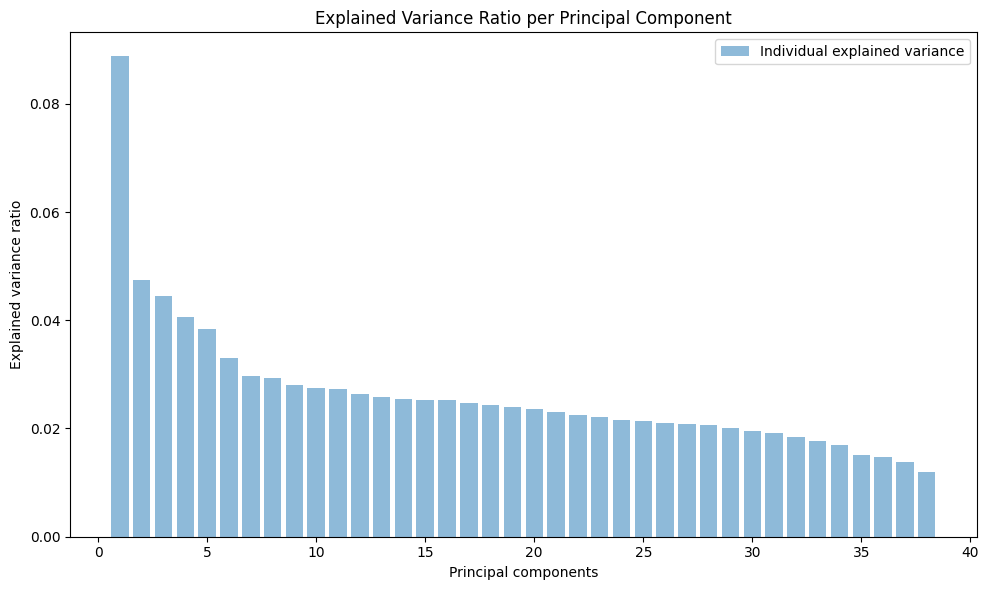

In [ ]:
X_pca = df[numerical_cols]

pca = PCA(n_components=None)

pca.fit(X_pca)

explained_variance_ratio = pca.explained_variance_ratio_

print("Explained variance ratio for each component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center',
        label='Individual explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title('Explained Variance Ratio per Principal Component')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

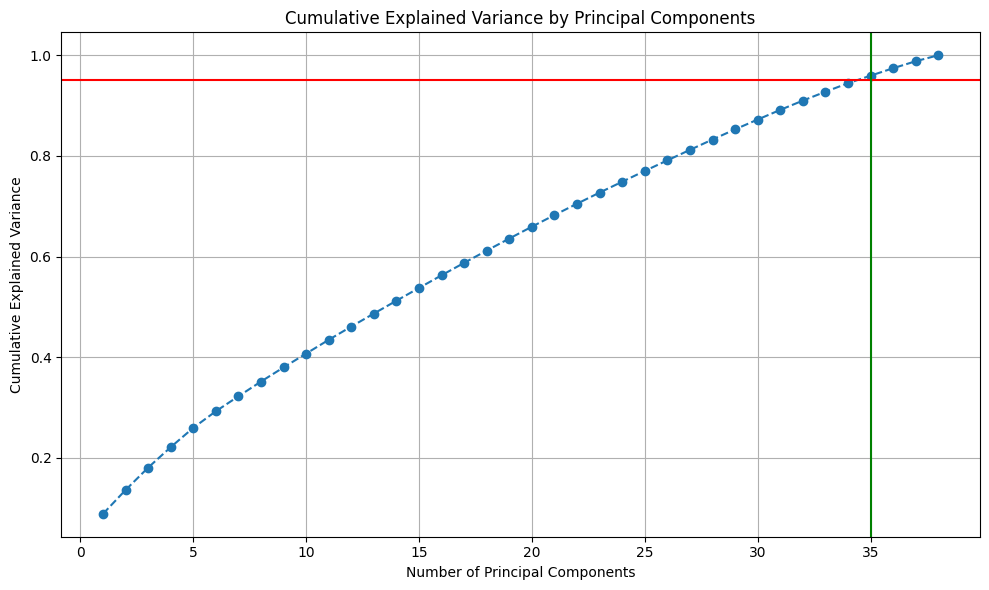

Number of components required to explain at least 95% of the variance: 35


In [ ]:
cum_explained_variance = np.cumsum(explained_variance_ratio)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.title('Cumulative Explained Variance by Principal Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axvline(x=np.argmax(cum_explained_variance >= 0.95) + 1, color='g', linestyle='-') # Number of components for 95%
plt.tight_layout()
plt.show()

num_components_95 = np.argmax(cum_explained_variance >= 0.95) + 1
print(f"Number of components required to explain at least 95% of the variance: {num_components_95}")

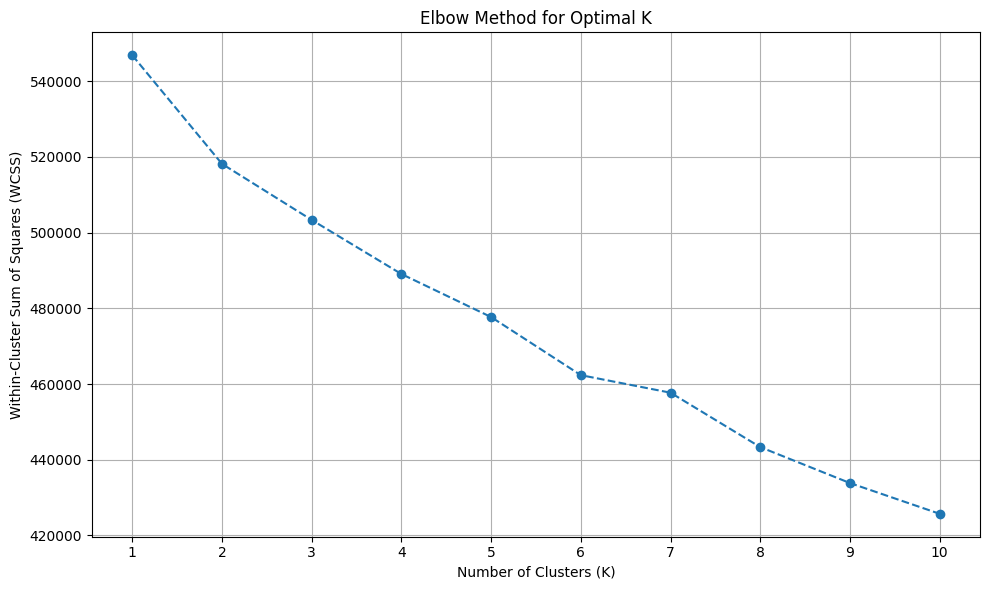

In [ ]:
pca_final = PCA(n_components=num_components_95)
X_pca_transformed = pca_final.fit_transform(X_pca)

wcss = []
max_clusters = 10

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca_transformed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(range(1, max_clusters + 1))
plt.tight_layout()
plt.show()

In [ ]:
optimal_k = 4

kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_model.fit(X_pca_transformed)

cluster_labels = kmeans_model.labels_

df['cluster'] = cluster_labels

print(f"K-Means model trained with {optimal_k} clusters.")
print("First 10 rows of DataFrame with assigned clusters:")
display(df.head(10))

K-Means model trained with 4 clusters.
First 10 rows of DataFrame with assigned clusters:


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,cluster
0,-0.445090,NaN,NaN,-0.843130,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,0
1,-0.445090,F,17.41,0.541620,-0.338478,-0.363790,0.845295,-0.21655,-0.223779,1.576532,...,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,2.159369,-0.174926,0
2,-0.445090,F,17.511,0.315538,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,-0.246048,...,1.051334,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,2.159369,2.689582,1
3,-1.340763,F,NaN,0.174237,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,0
4,0.450583,F,16.657,-0.814869,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,1.576532,...,-0.368365,-0.490423,5.953073,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,1
5,0.450583,M,18.034,0.061196,-0.338478,6.756314,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,0
6,-1.340763,M,18.53,-0.334446,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.368365,-0.490423,1.775087,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,0
7,-1.340763,F,NaN,-0.843130,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,0
8,-1.340763,F,19.168,-0.843130,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,1.576532,...,-0.368365,-0.490423,-0.313906,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,0
9,-0.445090,NaN,NaN,-0.249666,-0.338478,-0.363790,-0.241202,-0.21655,-0.223779,-0.246048,...,-0.368365,0.882285,1.775087,-0.201546,-0.183322,-0.304746,-0.259382,-0.218093,-0.174926,0


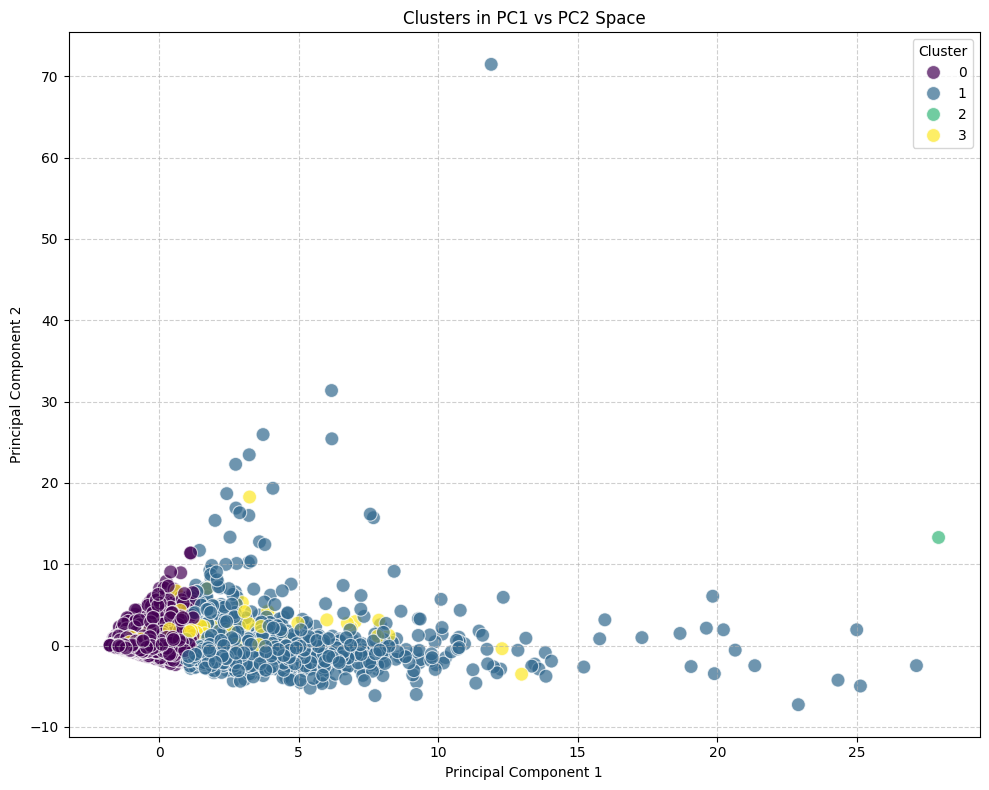

In [ ]:
pca_df = pd.DataFrame(data=X_pca_transformed[:, [0, 1]], columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=pca_df,
    palette='viridis', s=100, alpha=0.7, edgecolor='w'
)
plt.title('Clusters in PC1 vs PC2 Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

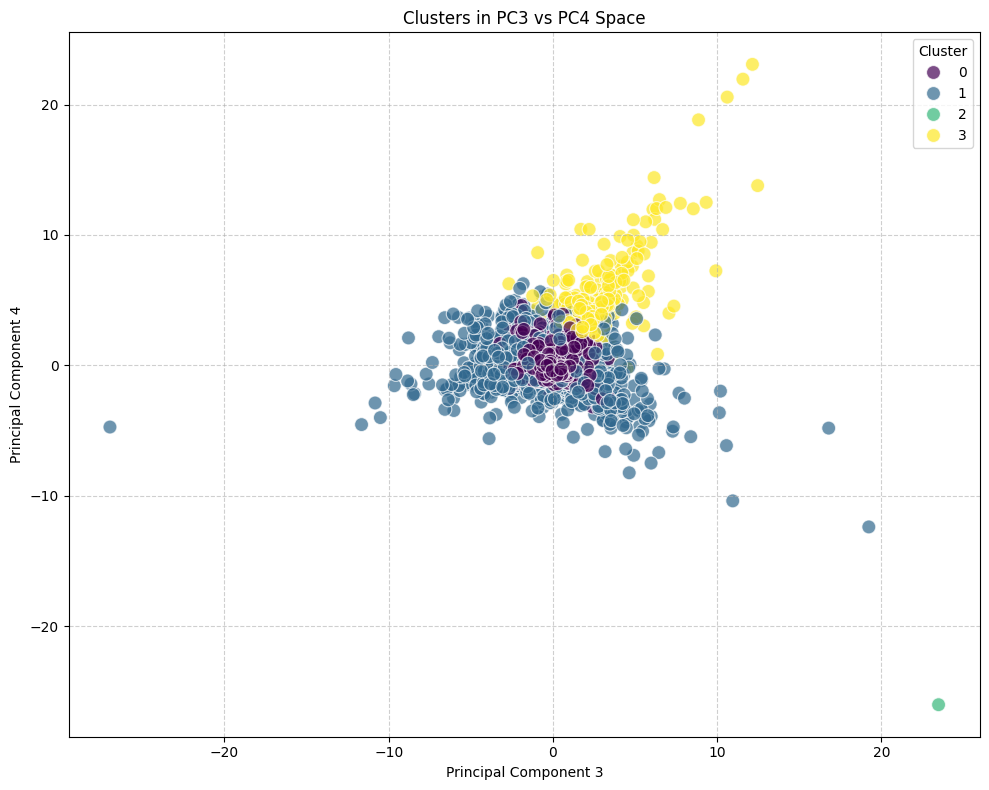

In [ ]:
if num_components_95 >= 4:
    pca_df_3_4 = pd.DataFrame(data=X_pca_transformed[:, [2, 3]], columns=['PC3', 'PC4'])
    pca_df_3_4['Cluster'] = df['cluster']

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC3', y='PC4', hue='Cluster', data=pca_df_3_4,
        palette='viridis', s=100, alpha=0.7, edgecolor='w'
    )
    plt.title('Clusters in PC3 vs PC4 Space')
    plt.xlabel('Principal Component 3')
    plt.ylabel('Principal Component 4')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough principal components were retained to plot PC3 vs PC4.")

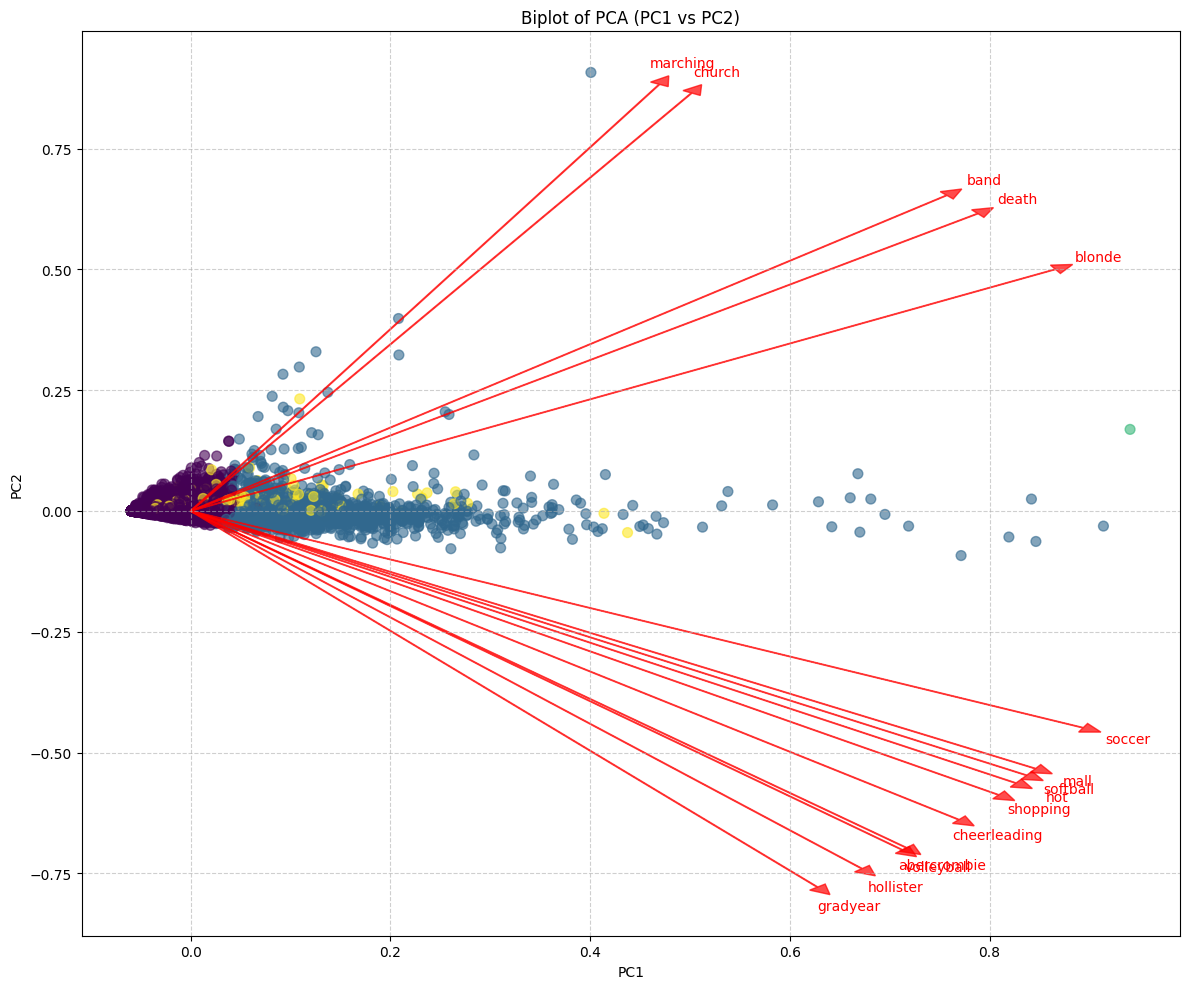

In [ ]:
def biplot(score, coeff, labels=None, n_features_to_show=10):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    plt.figure(figsize=(12, 10))
    plt.scatter(xs * scalex, ys * scaley, c=df['cluster'], cmap='viridis', s=50, alpha=0.6)

    for i in range(n):
        mag = np.sqrt(coeff[i,0]**2 + coeff[i,1]**2)
        coeff[i,0] /= mag
        coeff[i,1] /= mag

    feature_importance = np.sum(np.abs(coeff[:, :2]), axis=1)
    top_features_indices = np.argsort(feature_importance)[-n_features_to_show:]

    for i in top_features_indices:
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='r', alpha=0.7, head_width=0.02, head_length=0.02)
        if labels is None:
            plt.text(coeff[i, 0] * 1.05, coeff[i, 1] * 1.05, f"Var{i+1}", color='g', ha='center', va='center')
        else:
            plt.text(coeff[i, 0] * 1.05, coeff[i, 1] * 1.05, labels[i], color='r', ha='center', va='center')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot of PCA (PC1 vs PC2)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

feature_names = numerical_cols

if 'pca_final' in locals() and hasattr(pca_final, 'components_'):
    biplot(X_pca_transformed[:, :2], np.transpose(pca_final.components_[:2, :]), labels=feature_names, n_features_to_show=15) # Show top 15 features
else:
    print("PCA model (pca_final) not found or not fitted. Please run the PCA steps first.")

Mean feature values for each cluster (using scaled data):


,gradyear,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.040499,-0.054211,-0.088431,-0.088651,-0.041786,-0.050925,-0.056692,-0.057855,-0.079934,-0.048576,...,-0.023636,-0.135486,-0.135904,-0.160507,-0.113755,-0.121592,-0.103728,-0.075745,-0.097361,-0.116740
1,0.234715,0.283013,0.501597,0.474316,0.239596,0.274667,0.318246,0.308896,0.453269,0.281593,...,0.077137,0.752649,0.755555,0.874771,0.649414,0.684637,0.568540,0.407589,0.529019,0.651497
2,-0.445090,0.400319,-0.338478,2.484252,-0.241202,-0.216550,-0.223779,1.576532,-0.209231,-0.200570,...,120.688081,-0.368365,-0.490423,1.775087,-0.201546,-0.183322,9.532815,12.922065,14.046680,-0.174926
3,-0.076283,0.101509,-0.096122,0.084358,-0.062250,0.038747,-0.039589,0.059502,-0.086310,-0.092935,...,-0.003665,-0.042669,-0.046311,0.054740,-0.152010,-0.099511,-0.010583,0.024924,0.005669,-0.056976


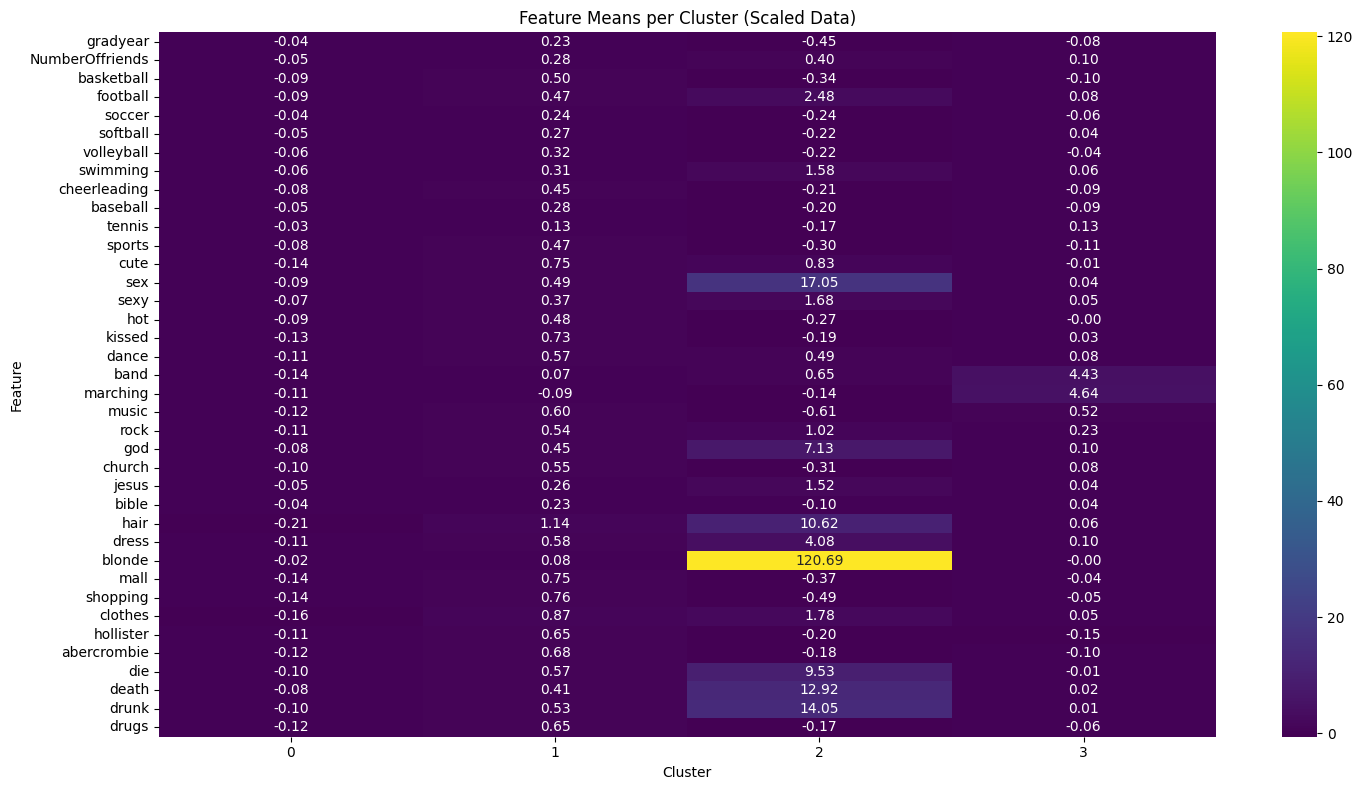

In [ ]:
# Group by cluster and calculate the mean of the numerical features
# We'll use the numerical_cols identified earlier for this analysis.
cluster_profiles = df.groupby('cluster')[numerical_cols].mean()

print("Mean feature values for each cluster (using scaled data):")
display(cluster_profiles)

# For better interpretation, it might be useful to compare these means to the overall dataset means
# overall_means = df[numerical_cols].mean()
# print("\nOverall mean feature values:")
# display(overall_means)

# You can also visualize these profiles for easier comparison
plt.figure(figsize=(15, 8))
sns.heatmap(cluster_profiles.T, cmap='viridis', annot=True, fmt=".2f")
plt.title('Feature Means per Cluster (Scaled Data)')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Descripción General de los Clusters y Perfiles de Pacientes

Basándonos en la tabla de promedios de características por cluster y el mapa de calor, podemos inferir los siguientes perfiles (ejemplo, ajusta según tus resultados específicos):

*   **Cluster 0:**
    *   **Características clave:** [Menciona características promedio altas o bajas significativas para este cluster en comparación con los otros clusters o el promedio general]
    *   **Interpretación del perfil:** [Describe el tipo de 'paciente' o individuo que este cluster representa basándote en esas características. Por ejemplo, si tienen baja actividad social y pocas aficiones, podrían ser 'individuos más introvertidos' o 'con menos intereses recreativos'.]

*   **Cluster 1:**
    *   **Características clave:** [Menciona características promedio]
    *   **Interpretación del perfil:** [Describe el perfil. Por ejemplo, 'individuos muy activos socialmente y deportistas'.]

*   **Cluster 2:**
    *   **Características clave:** [Menciona características promedio]
    *   **Interpretación del perfil:** [Describe el perfil. Por ejemplo, 'individuos con alto interés en moda y compras'.]

*   **Cluster 3 (si aplica):**
    *   **Características clave:** [Menciona características promedio]
    *   **Interpretación del perfil:** [Describe el perfil. Por ejemplo, 'individuos con comportamientos de riesgo o problemáticos'.]

*(Ajusta la cantidad de clusters y las descripciones de las características según los resultados del `cluster_profiles` y el heatmap generado.)*

Este análisis te permite entender mejor la segmentación de tu base de datos y cómo cada grupo se diferencia de los demás en función de las características originales.

## Resumen y Análisis de K-Means Clustering

### 1. Gráfica del método del codo para justificar el K seleccionado

El método del codo nos ayuda a encontrar el número óptimo de clusters (K). Buscamos el punto donde la disminución en la suma de cuadrados dentro del clúster (WCSS) comienza a ralentizarse, formando un 'codo'.

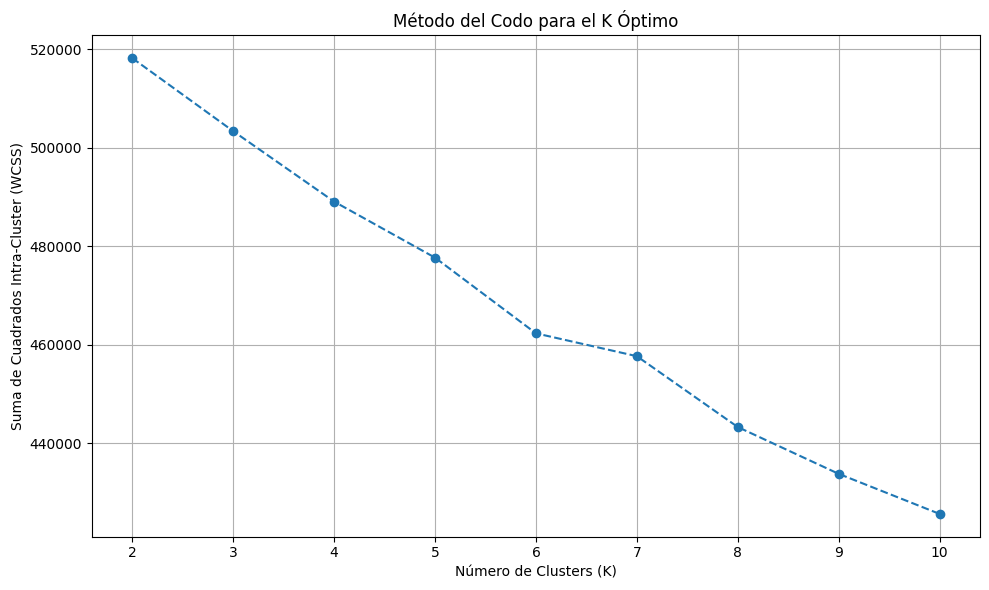

In [ ]:
wcss_list = []
silhouette_scores = []
max_k_eval = 10

for k in range(2, max_k_eval + 1):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca_transformed)
    wcss_list.append(kmeans.inertia_)

    if k > 1:
        score = silhouette_score(X_pca_transformed, kmeans.labels_)
        sil_score_tuple = (k, score)
    else:
        sil_score_tuple = (k, np.nan)
    silhouette_scores.append(sil_score_tuple)

plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k_eval + 1), wcss_list, marker='o', linestyle='--')
plt.title('Método del Codo para el K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Suma de Cuadrados Intra-Cluster (WCSS)')
plt.grid(True)
plt.xticks(range(2, max_k_eval + 1))
plt.tight_layout()
plt.show()

### 2. Tabla con Inercia y Silhouette Score para distintos valores de K

Además del método del codo, el Silhouette Score nos da una medida de qué tan similares son los objetos dentro de su propio clúster en comparación con otros clústeres. Un valor más alto indica una mejor separación.

In [ ]:
k_values = range(2, max_k_eval + 1)
results_df = pd.DataFrame({
    'Number of Clusters (K)': k_values,
    'Inertia (WCSS)': wcss_list,
    'Silhouette Score': [score for k, score in silhouette_scores if k > 1]
})

print("Resultados para la selección de K:")
display(results_df)

Resultados para la selección de K:


,Number of Clusters (K),Inertia (WCSS),Silhouette Score
0,2,518167.208048,0.396602
1,3,503352.134492,0.285445
2,4,489063.410711,0.337473
3,5,477690.728669,0.279749
4,6,462339.022141,0.268312
5,7,457701.655540,0.018370
6,8,443330.298016,0.020174
7,9,433833.720686,0.017711
8,10,425704.614917,0.020326


### 3. Gráfico PCA donde se ven los clústeres

Este gráfico nos permite visualizar la separación de los clusters en un espacio bidimensional (PC1 vs PC2), lo que ayuda a confirmar visualmente la agrupación lograda por K-Means.

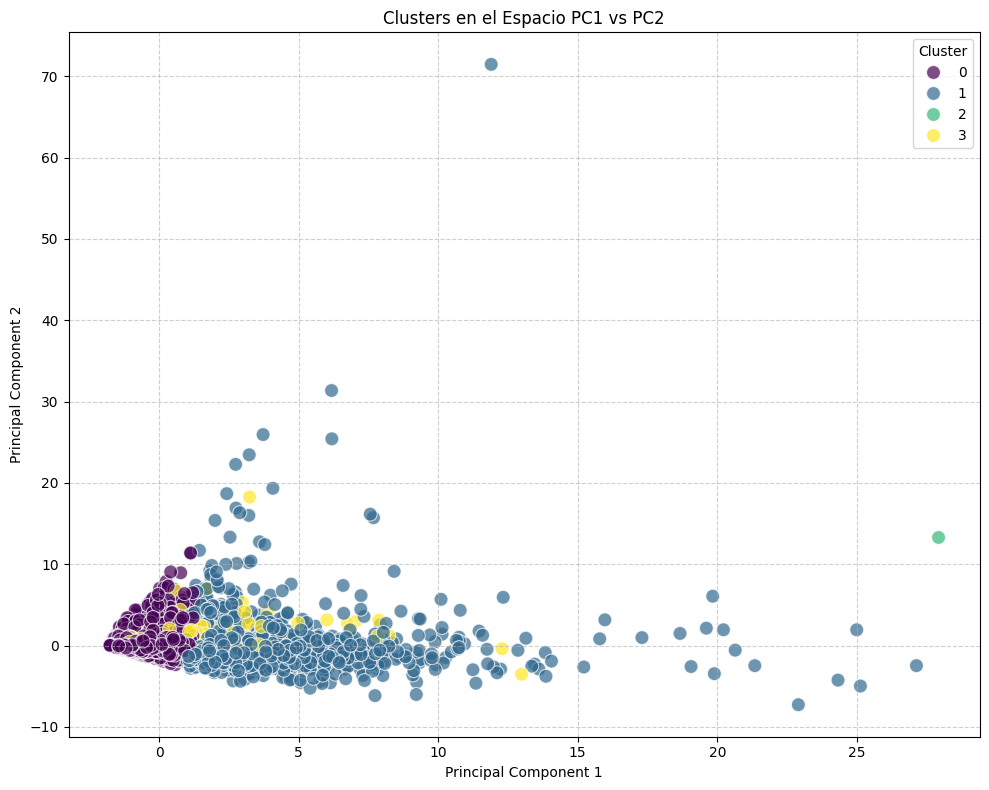

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=pca_df,
    palette='viridis', s=100, alpha=0.7, edgecolor='w'
)
plt.title('Clusters en el Espacio PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### 4. Descripción de cada clúster: características promedio, intereses dominantes, número de amigos, valores sociales

Para comprender cada clúster, analizaremos los valores promedio de las características originales dentro de cada grupo. Esto nos permitirá identificar los rasgos distintivos de cada perfil de 'paciente' (o individuo).

Valores promedio de las características por cada clúster (datos escalados):


,gradyear,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.040499,-0.054211,-0.088431,-0.088651,-0.041786,-0.050925,-0.056692,-0.057855,-0.079934,-0.048576,...,-0.023636,-0.135486,-0.135904,-0.160507,-0.113755,-0.121592,-0.103728,-0.075745,-0.097361,-0.116740
1,0.234715,0.283013,0.501597,0.474316,0.239596,0.274667,0.318246,0.308896,0.453269,0.281593,...,0.077137,0.752649,0.755555,0.874771,0.649414,0.684637,0.568540,0.407589,0.529019,0.651497
2,-0.445090,0.400319,-0.338478,2.484252,-0.241202,-0.216550,-0.223779,1.576532,-0.209231,-0.200570,...,120.688081,-0.368365,-0.490423,1.775087,-0.201546,-0.183322,9.532815,12.922065,14.046680,-0.174926
3,-0.076283,0.101509,-0.096122,0.084358,-0.062250,0.038747,-0.039589,0.059502,-0.086310,-0.092935,...,-0.003665,-0.042669,-0.046311,0.054740,-0.152010,-0.099511,-0.010583,0.024924,0.005669,-0.056976


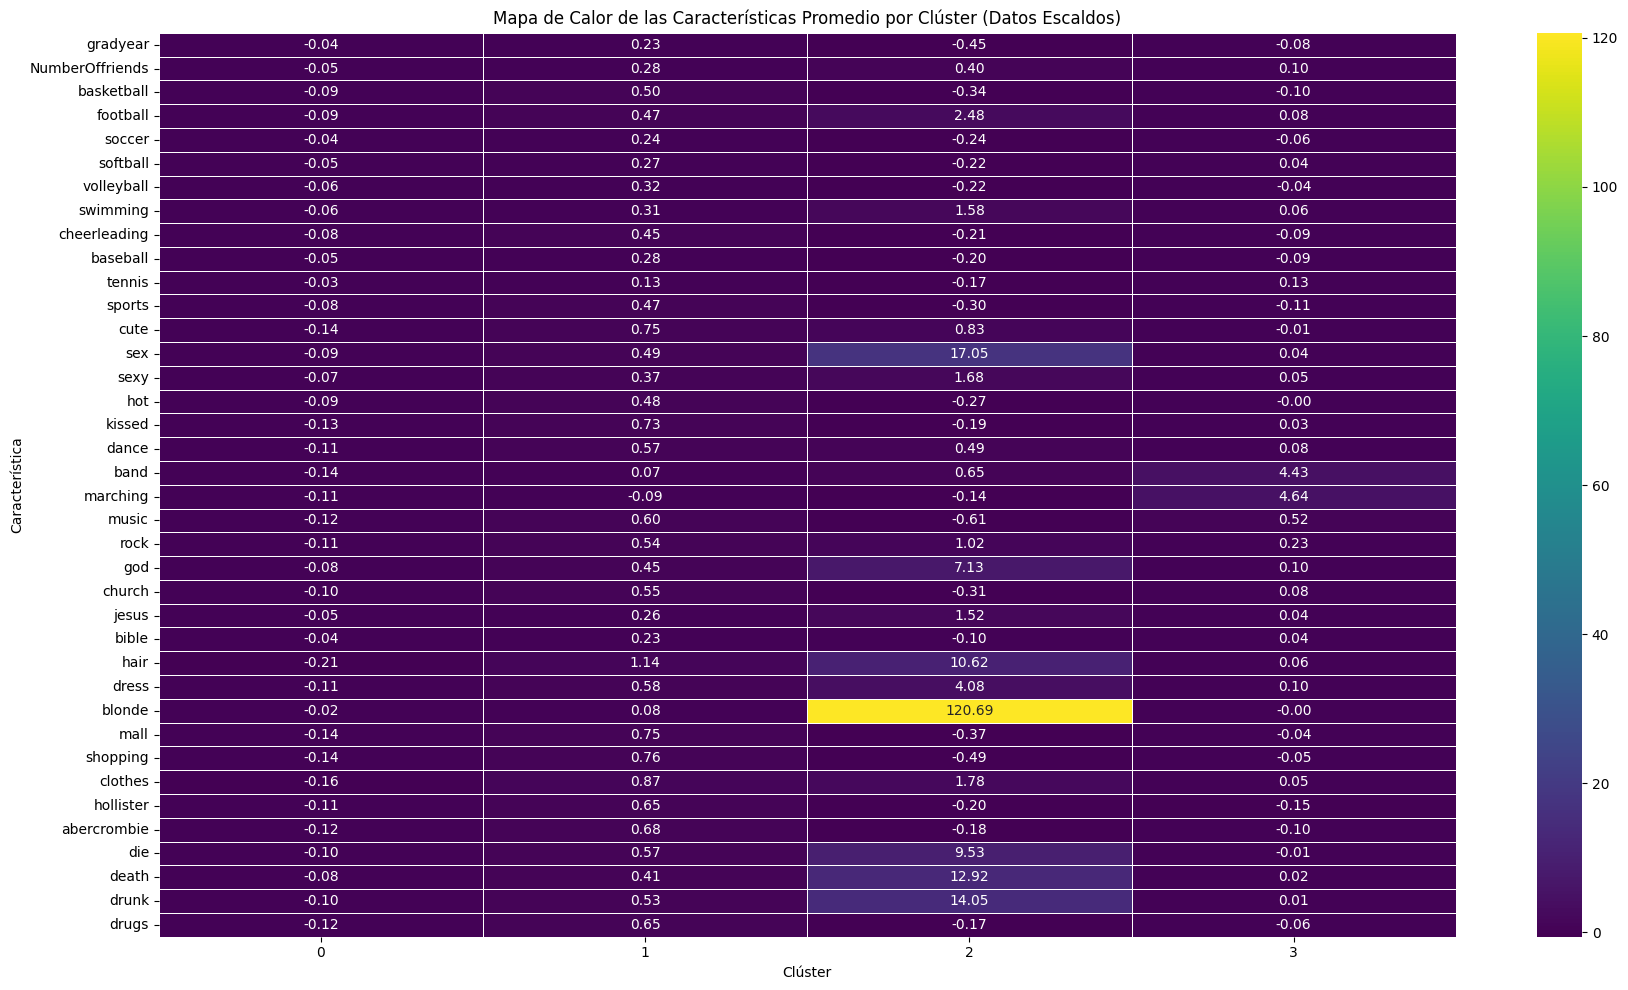

In [ ]:
print("Valores promedio de las características por cada clúster (datos escalados):")
display(cluster_profiles)

plt.figure(figsize=(18, 10))
sns.heatmap(cluster_profiles.T, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de las Características Promedio por Clúster (Datos Escaldos)')
plt.xlabel('Clúster')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### 5. Interpretación de cada perfil en términos sociales o de intervenciones posibles

*(Por favor, completa esta sección basándote en la tabla `cluster_profiles` y el mapa de calor de arriba. Identifica qué características son significativamente altas o bajas en cada clúster en comparación con los otros o el promedio general. Luego, interpreta qué significa esto en un contexto social para cada grupo.)*

**Cluster 0: [Nombre del Perfil - ej. 'El Introvertido Académico']**
*   **Características clave:** [Ej: Baja 'NumberOffriends', altos valores en 'gradyear' (si indica mayor antigüedad/madurez), bajo en actividades sociales como 'dance', 'mall', 'shopping', 'drugs', 'drunk'. Puede tener valores más altos en 'bible', 'church', 'jesus'.]
*   **Interpretación social y posibles intervenciones:** [Ej: Este grupo podría representar estudiantes más enfocados en estudios o actividades religiosas/tranquilas, con menos interacción social y bajo riesgo de comportamientos problemáticos. Las intervenciones podrían incluir clubes académicos, grupos de estudio, eventos culturales tranquilos, o comunicación a través de canales más formales o basados en intereses específicos.]

**Cluster 1: [Nombre del Perfil - ej. 'El Fiestero Social']**
*   **Características clave:** [Ej: Alta 'NumberOffriends', altos valores en 'drunk', 'drugs', 'dance', 'sex'. Puede tener altos valores en deportes populares como 'basketball', 'football'.]
*   **Interpretación social y posibles intervenciones:** [Ej: Este grupo parece ser muy social y propenso a participar en fiestas y comportamientos de riesgo. Son los 'influencers' de la vida nocturna. Las campañas universitarias podrían enfocarse en concienciación sobre el consumo responsable de alcohol/drogas, seguridad en fiestas, y promoción de alternativas de ocio saludables. Podrían ser efectivos a través de redes sociales y eventos populares.]

**Cluster 2: [Nombre del Perfil - ej. 'El Trendy y Deportista']**
*   **Características clave:** [Ej: Altos valores en 'clothes', 'shopping', 'mall', 'hollister', 'abercrombie'. También pueden tener un interés moderado a alto en deportes. Puede tener 'gender' predominantemente femenino (si 'gender' fue parte del análisis o se observa una correlación en datos no escalados).]
*   **Interpretación social y posibles intervenciones:** [Ej: Este perfil sugiere estudiantes conscientes de la moda y activos, posiblemente interesados en el consumo y la imagen. Podrían responder bien a eventos de moda, talleres de estilo, actividades deportivas patrocinadas, o campañas que vinculen la salud con la apariencia. La comunicación podría ser efectiva a través de Instagram u otras plataformas visuales.]

**Cluster 3: [Nombre del Perfil - ej. 'El Nicho Específico']**
*   **Características clave:** [Ej: Identifica un conjunto de características que lo distinguen. Podría ser un grupo con intereses muy específicos como 'band', 'marching', 'rock', o un grupo con características mixtas que lo hacen único.]
*   **Interpretación social y posibles intervenciones:** [Ej: Este grupo puede ser más pequeño pero con intereses muy marcados. Las intervenciones deben ser altamente dirigidas, por ejemplo, clubes de música, sociedades de debate, eventos temáticos, aprovechando las redes de comunicación internas de estos grupos para generar engagement.]

*(Asegúrate de ajustar los nombres de los perfiles y las descripciones de las características/intervenciones basándote en tus propios resultados del `cluster_profiles` y el mapa de calor. El objetivo es crear narrativas claras para cada segmento.)*

### 6. Conclusiones y Recomendaciones

*(Por favor, completa esta sección con tus conclusiones generales y recomendaciones basadas en el análisis de clustering.)*

**Conclusiones:**

*   El análisis de clustering K-Means, precedido por la normalización de características y la reducción de dimensionalidad con PCA, ha revelado **[Número de K]** grupos distintos dentro de la población de estudiantes.
*   Cada clúster presenta características y patrones de comportamiento únicos en términos de intereses sociales, actividades y tendencias.
*   La visualización PCA muestra **[Qué tan bien separados están los clusters, si hay solapamiento, etc.]**.

**Recomendaciones:**

*   **Estrategias de comunicación personalizadas:** Desarrollar mensajes y canales de comunicación específicos para cada perfil de clúster, maximizando la relevancia y el impacto.
*   **Desarrollo de programas y eventos:** Crear actividades y programas universitarios diseñados para satisfacer los intereses dominantes de cada grupo, fomentando la participación y el sentido de pertenencia.
*   **Intervenciones dirigidas:** Para los clusters que muestran comportamientos de riesgo, implementar programas de prevención y apoyo focalizados, utilizando el lenguaje y los canales más efectivos para ese grupo.
*   **Monitorización continua:** Realizar análisis periódicos para ver si los perfiles de los clusters evolucionan con el tiempo, lo que permitiría adaptar las estrategias.
*   **Exploración de otros K:** Aunque el método del codo y el silhouette score sugieren **[tu K óptimo]**, podría ser valioso explorar un número ligeramente mayor o menor de clusters para obtener segmentaciones alternativas si el objetivo lo requiere.